In [16]:
# --- notebook setup ---
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

DB_PATH = "../data/training.sqlite"
conn = sqlite3.connect(DB_PATH)

print("Connected to:", DB_PATH)


Connected to: ../data/training.sqlite


In [17]:
from pathlib import Path

# repo root is the parent of notebooks
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

PLOTS_DIR = REPO_ROOT / "docs"/ "assets" / "plots"
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

print("Saving plots to:", PLOTS_DIR)

Saving plots to: /Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/docs/assets/plots


In [18]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)

,name
0,alerts
1,forecast_bands
2,sets
3,sqlite_sequence
4,weekly_e1rm


In [19]:
# Cell A - Load needed tables

weekly = pd.read_sql_query(
    "SELECT week_start, exercise, e1rm FROM weekly_e1rm ORDER BY week_start, exercise;", conn
)

bands = pd.read_sql_query(
    "SELECT week_start, exercise, scenario, p5, p10, p50, p90, p95 FROM forecast_bands ORDER BY week_start, exercise, scenario;", conn      
)

weekly["week_start"] = pd.to_datetime(weekly["week_start"])
bands["week_start"] = pd.to_datetime(bands["week_start"])

weekly.head(), bands.head()

(  week_start     exercise        e1rm
 0 2026-02-02  Bench Press  116.666667
 1 2026-02-02     Deadlift  204.166667
 2 2026-02-02        Squat  160.416667
 3 2026-02-09  Bench Press  115.500000
 4 2026-02-09     Deadlift  203.500000,
   week_start     exercise scenario          p5         p10         p50  \
 0 2026-03-09  Bench Press     100%  120.166667  120.166667  120.166667   
 1 2026-03-09  Bench Press      50%  120.166667  120.166667  120.166667   
 2 2026-03-09  Bench Press      75%  120.166667  120.166667  120.166667   
 3 2026-03-09     Deadlift     100%  210.000000  210.000000  210.000000   
 4 2026-03-09     Deadlift      50%  210.000000  210.000000  210.000000   
 
           p90         p95  
 0  120.166667  120.166667  
 1  120.166667  120.166667  
 2  120.166667  120.166667  
 3  210.000000  210.000000  
 4  210.000000  210.000000  )

In [20]:
# Forecast Logic check

bands[(bands["exercise"]=="Bench Press") & (bands["week_start"]>"2026-03-02")].head(9) 


,week_start,exercise,scenario,p5,p10,p50,p90,p95
0,2026-03-09,Bench Press,100%,120.166667,120.166667,120.166667,120.166667,120.166667
1,2026-03-09,Bench Press,50%,120.166667,120.166667,120.166667,120.166667,120.166667
2,2026-03-09,Bench Press,75%,120.166667,120.166667,120.166667,120.166667,120.166667
9,2026-03-16,Bench Press,100%,117.927416,118.542356,120.733344,122.991417,123.606822
10,2026-03-16,Bench Press,50%,117.678717,118.293657,120.484645,122.742718,123.358123
11,2026-03-16,Bench Press,75%,117.803067,118.418007,120.608995,122.867067,123.482473
18,2026-03-23,Bench Press,100%,117.480721,118.298166,120.958603,123.688709,124.628330
19,2026-03-23,Bench Press,50%,117.118242,117.935687,120.596124,123.326230,124.265851
20,2026-03-23,Bench Press,75%,117.299482,118.116926,120.777364,123.507470,124.447091


In [21]:
# Ordering logic check:

bench = bands[bands["exercise"]=="Bench Press"].pivot_table(
    index="week_start", columns="scenario", values="p50"
).sort_index()

bench.head(6)

scenario,100%,50%,75%
week_start,,,
2026-03-09,120.166667,120.166667,120.166667
2026-03-16,120.733344,120.484645,120.608995
2026-03-23,120.958603,120.596124,120.777364
2026-03-30,121.195038,120.723986,120.959512
2026-04-06,121.345260,120.769950,121.057605
2026-04-13,121.556455,120.880537,121.218496


In [22]:
squat = bands[bands["exercise"]=="Squat"].pivot_table(
    index="week_start", columns="scenario", values="p50"
).sort_index()

squat.head(6)

scenario,100%,50%,75%
week_start,,,
2026-03-09,181.133333,181.133333,181.133333
2026-03-16,181.994896,181.621847,181.808372
2026-03-23,182.332402,181.788683,182.060542
2026-03-30,182.690269,181.983690,182.336979
2026-04-06,182.905886,182.042920,182.474403
2026-04-13,183.224342,182.210465,182.717403


In [23]:
bands[bands.exercise=="Bench Press"].pivot(
    index="week_start", columns="scenario", values="p50"
).round(2)

scenario,100%,50%,75%
week_start,,,
2026-03-09,120.17,120.17,120.17
2026-03-16,120.73,120.48,120.61
2026-03-23,120.96,120.60,120.78
2026-03-30,121.20,120.72,120.96
2026-04-06,121.35,120.77,121.06
2026-04-13,121.56,120.88,121.22
2026-04-20,121.75,120.98,121.37
2026-04-27,121.94,121.08,121.51
2026-05-04,122.10,121.14,121.62


In [24]:
wk = weekly.copy()

wk = wk.sort_values(["exercise", "week_start"])
wk["diff"] = wk.groupby("exercise")["e1rm"].diff()
wk

,week_start,exercise,e1rm,diff
0,2026-02-02,Bench Press,116.666667,NaN
3,2026-02-09,Bench Press,115.500000,-1.166667
6,2026-02-16,Bench Press,123.750000,8.250000
9,2026-02-23,Bench Press,81.666667,-42.083333
12,2026-03-02,Bench Press,120.166667,38.500000
1,2026-02-02,Deadlift,204.166667,NaN
4,2026-02-09,Deadlift,203.500000,-0.666667
7,2026-02-16,Deadlift,217.800000,14.300000
10,2026-02-23,Deadlift,145.833333,-71.966667
13,2026-03-02,Deadlift,210.000000,64.166667


In [25]:
# Cell B: Plots

def plot_lift(exercise: str, scenario: str = "75%"):
    w = weekly[weekly["exercise"] == exercise].sort_values("week_start")
    b = bands[(bands["exercise"] == exercise) & (bands["scenario"] == scenario)].sort_values("week_start")
    
    if w.empty:
        print(f"No weekly data for {exercise}")
        return

    if b.empty:
        print(f"No forecast data for {exercise} / {scenario}")
        return

    plt.figure()
    plt.plot(w["week_start"], w["e1rm"], marker="o", label="Actual weekly e1rm")
    plt.plot(b["week_start"], b["p50"], label=f"Forecast {scenario}")
    plt.fill_between(b["week_start"], b["p10"], b["p90"], alpha=0.2, label=f"Forecast {scenario} 10-90% band")
    
    plt.title(f"{exercise}: Actual vs Forecast ({scenario})")
    plt.xlabel("Week start")
    plt.ylabel("e1RM (kg)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{exercise.lower().replace(' ', '_')}_forecast.png", dpi=200)
    plt.show()

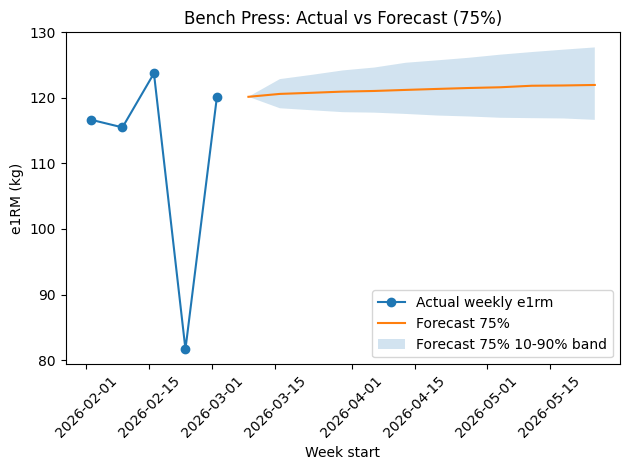

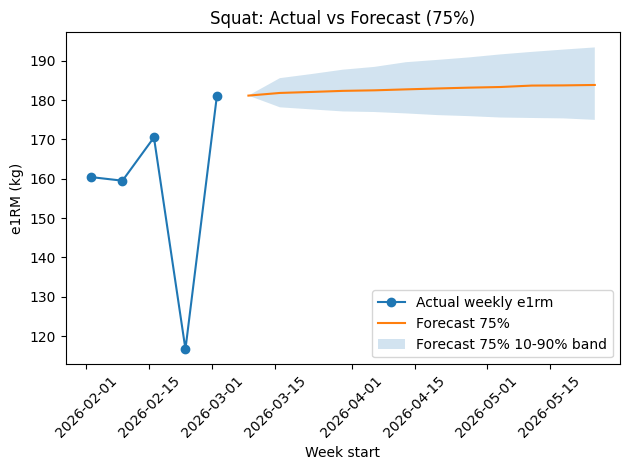

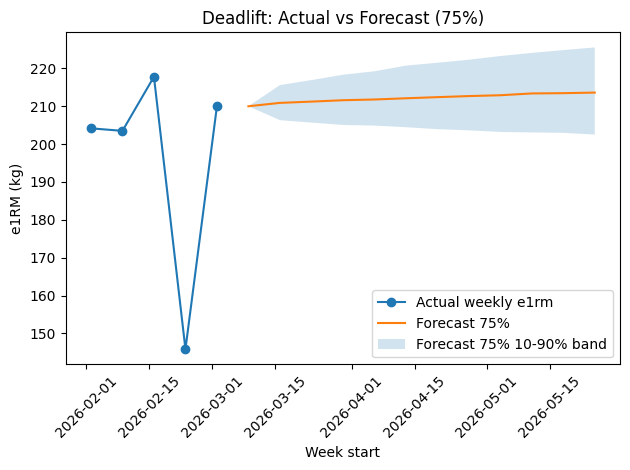

In [26]:
# Run for all lifts

for lift in ["Bench Press", "Squat", "Deadlift"]:
    plot_lift(lift, scenario="75%")

In [27]:
sorted([p.name for p in PLOTS_DIR.glob("*.png")])

['bench_press_forecast.png', 'deadlift_forecast.png', 'squat_forecast.png']

In [28]:
import os
from pathlib import Path

print("Notebook CWD:", os.getcwd())
print("PLOTS_DIR absolute:", PLOTS_DIR.resolve())
print("Files:", list(PLOTS_DIR.glob("*.png")))

Notebook CWD: /Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/notebooks
PLOTS_DIR absolute: /Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/docs/assets/plots
Files: [PosixPath('/Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/docs/assets/plots/squat_forecast.png'), PosixPath('/Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/docs/assets/plots/bench_press_forecast.png'), PosixPath('/Users/somtonwandu/myrepo/Strength_training_analytics/Strength-progression-forecast/docs/assets/plots/deadlift_forecast.png')]


In [29]:
# KPI table

weekly = pd.read_sql_query(
    "SELECT week_start, exercise, e1rm FROM weekly_e1rm ORDER BY week_start, exercise;",
    conn
)
bands = pd.read_sql_query(
    """
    SELECT week_start, exercise, scenario, p10, p50, p90
    FROM forecast_bands
    WHERE scenario = '75%'
    ORDER BY week_start, exercise;
    """,
    conn
)

conn.close()

weekly["week_start"] = pd.to_datetime(weekly["week_start"])
bands["week_start"] = pd.to_datetime(bands["week_start"])

# latest actual per lift
latest_actual = (
    weekly.sort_values("week_start")
    .groupby("exercise", as_index=False)
    .tail(1)
    .rename(columns={"week_start": "latest_week", "e1rm": "latest_e1rm"})
)

# forecast p50 at horizon (last forecast week) per lift
last_forecast_week = bands["week_start"].max()
horizon = (
    bands[bands["week_start"] == last_forecast_week]
    .copy()
    .rename(columns={"week_start": "forecast_week", "p50": "forecast_p50"})
)

horizon["band_width_p90_p10"] = horizon["p90"] - horizon["p10"]

kpis = latest_actual.merge(
    horizon[["exercise", "forecast_week", "forecast_p50", "band_width_p90_p10"]],
    on="exercise",
    how="left",
)

kpis = kpis.sort_values("exercise")
kpis

,latest_week,exercise,latest_e1rm,forecast_week,forecast_p50,band_width_p90_p10
0,2026-03-02,Bench Press,120.166667,2026-05-25,121.972638,11.049874
1,2026-03-02,Deadlift,210.000000,2026-05-25,213.609272,23.020571
2,2026-03-02,Squat,181.133333,2026-05-25,183.836951,18.416457


In [30]:
# Convert KPIs into Markdown table for README

kpis_display = kpis.copy()
kpis_display["latest_e1rm"] = kpis_display["latest_e1rm"].round(1)
kpis_display["forecast_p50"] = kpis_display["forecast_p50"].round(1)
kpis_display["band_width_p90_p10"] = kpis_display["band_width_p90_p10"].round(1)

md_table = kpis_display.rename(columns={
    "exercise": "Lift",
    "latest_week": "Latest week",
    "latest_e1rm": "Latest e1RM (kg)",
    "forecast_week": "Forecast horizon week",
    "forecast_p50": "Forecast p50 (kg)",
    "band_width_p90_p10": "Uncertainty width p90-p10 (kg)",
})[[
    "Lift",
    "Latest week",
    "Latest e1RM (kg)",
    "Forecast horizon week",
    "Forecast p50 (kg)",
    "Uncertainty width p90-p10 (kg)",
]].to_markdown(index=False)

print(md_table)

| Lift        | Latest week         |   Latest e1RM (kg) | Forecast horizon week   |   Forecast p50 (kg) |   Uncertainty width p90-p10 (kg) |
|:------------|:--------------------|-------------------:|:------------------------|--------------------:|---------------------------------:|
| Bench Press | 2026-03-02 00:00:00 |              120.2 | 2026-05-25 00:00:00     |               122   |                             11   |
| Deadlift    | 2026-03-02 00:00:00 |              210   | 2026-05-25 00:00:00     |               213.6 |                             23   |
| Squat       | 2026-03-02 00:00:00 |              181.1 | 2026-05-25 00:00:00     |               183.8 |                             18.4 |
